In [1]:
import os
import cv2
import numpy as np

def remove_text_annotations(img):
    """Erases text labels using Top-Hat filtering without altering tissue."""
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (5, 5))
    tophat = cv2.morphologyEx(img, cv2.MORPH_TOPHAT, kernel)
    _, text_mask = cv2.threshold(tophat, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    contours, _ = cv2.findContours(text_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    clean_mask = np.zeros_like(img)
    for cnt in contours:
        if 5 < cv2.contourArea(cnt) < 200:
            cv2.drawContours(clean_mask, [cnt], -1, 255, thickness=cv2.FILLED)

    kernel_dilate = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
    clean_mask = cv2.dilate(clean_mask, kernel_dilate, iterations=1)
    return cv2.inpaint(img, clean_mask, inpaintRadius=2, flags=cv2.INPAINT_TELEA)

def preprocess_image(img_path):
    img_raw = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if img_raw is None:
        return None

    # 1. Standardize resolution to 256x256
    img_resized = cv2.resize(img_raw, (256, 256))

    # 2. Text Removal
    no_text = remove_text_annotations(img_resized)

    # 3. Micro-Denoising (Preserves sharp edges)
    denoised = cv2.fastNlMeansDenoising(no_text, h=3, templateWindowSize=7, searchWindowSize=21)

    # 4. Laplacian Edge Sharpening & CLAHE
    sharpen_kernel = np.array([[0, -1, 0], [-1, 5, -1], [0, -1, 0]])
    sharpened = cv2.filter2D(denoised, -1, sharpen_kernel)

    clahe = cv2.createCLAHE(clipLimit=2.5, tileGridSize=(8, 8))
    preprocessed = clahe.apply(sharpened)

    return preprocessed

In [6]:
import cv2
import numpy as np
from skimage.segmentation import chan_vese

def isolate_cardiac_roi(img):
    """
    Crops out the top metadata banner (approx top 15%)
    and side depth scales (5% left/right) where UI text sits.
    """
    h, w = img.shape
    # Mask out top UI banner (0 to 18% height)
    top_crop = int(h * 0.18)
    # Mask out side depth bars (left/right 5%)
    side_crop = int(w * 0.05)

    # Create ROI mask
    roi_mask = np.ones_like(img, dtype=bool)
    roi_mask[:top_crop, :] = False
    roi_mask[:, :side_crop] = False
    roi_mask[:, w-side_crop:] = False

    # Apply ROI
    img_roi = img.copy()
    img_roi[~roi_mask] = 0
    return img_roi, roi_mask

def segment_clean_cardiac_chambers(img_path):
    img_raw = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if img_raw is None:
        return None, None

    img_resized = cv2.resize(img_raw, (256, 256))

    # Step 1: Zero-out the UI banners and metadata regions
    img_roi, roi_mask = isolate_cardiac_roi(img_resized)

    # Step 2: Normalize ROI to [0, 1]
    img_float = img_roi.astype(np.float32) / 255.0

    # Step 3: Chan-Vese with tight bounds and low smoothing
    cv_mask = chan_vese(
        img_float,
        mu=0.01,           # Allows tight tracking around internal chamber walls
        lambda1=1.0,
        lambda2=1.2,
        tol=1e-4,
        max_num_iter=200,
        dt=0.5,
        init_level_set="checkerboard"
    )[0]

    # Step 4: Force non-ROI regions (UI banner area) to remain BLACK (0)
    final_mask = (cv_mask & roi_mask).astype(np.uint8) * 255

    # Step 5: Post-processing (Remove tiny noise specks < 50 pixels)
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(final_mask)
    clean_mask = np.zeros_like(final_mask)
    for i in range(1, num_labels):
        if stats[i, cv2.CC_STAT_AREA] >= 60: # Keep only significant regions
            clean_mask[labels == i] = 255

    return img_resized, clean_mask

In [7]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler

def extract_dense_sift(img, step_size=8):
    sift = cv2.SIFT_create()
    keypoints = [
        cv2.KeyPoint(float(x), float(y), step_size)
        for y in range(0, img.shape[0], step_size)
        for x in range(0, img.shape[1], step_size)
    ]
    _, descriptors = sift.compute(img, keypoints)
    return descriptors

def build_feature_matrix(image_list, num_features=6, num_words=16):
    all_des, img_des_list = [], []

    for img in image_list:
        des = extract_dense_sift(img)
        if des is not None:
            all_des.append(des)
            img_des_list.append(des)

    # Build Visual Codebook
    kmeans = KMeans(n_clusters=num_words, random_state=42, n_init=10)
    kmeans.fit(np.vstack(all_des))

    # Generate BoVW Histograms
    histograms = []
    for des in img_des_list:
        words = kmeans.predict(des)
        hist, _ = np.histogram(words, bins=range(num_words + 1), density=True)
        histograms.append(hist)

    # PCA Dimensionality Reduction
    pca = PCA(n_components=num_features, random_state=42)
    pca_features = pca.fit_transform(np.array(histograms))

    # Min-Max Scaling to [0, pi]
    scaler = MinMaxScaler(feature_range=(0, np.pi))
    return scaler.fit_transform(pca_features)

In [8]:
from sklearn.model_selection import StratifiedKFold, LeaveOneOut, cross_validate
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Classifiers Configuration
classifiers = {
    "SVM (RBF)": SVC(kernel='rbf', probability=True, C=1.0, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=50, max_depth=3, random_state=42),
    "XGBoost": XGBClassifier(n_estimators=30, max_depth=2, eval_metric='logloss', random_state=42)
}

def evaluate_pipeline(X, y):
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

    print("="*65)
    print("                5-FOLD CROSS-VALIDATION RESULTS")
    print("="*65)

    for name, model in classifiers.items():
        scores = cross_validate(model, X, y, cv=skf, scoring=scoring)
        print(f"\nModel: {name}")
        print(f"  • Accuracy:  {np.mean(scores['test_accuracy']):.4f} (± {np.std(scores['test_accuracy']):.4f})")
        print(f"  • Precision: {np.mean(scores['test_precision']):.4f}")
        print(f"  • Recall:    {np.mean(scores['test_recall']):.4f}")
        print(f"  • F1-Score:  {np.mean(scores['test_f1']):.4f}")
        print(f"  • ROC-AUC:   {np.mean(scores['test_roc_auc']):.4f}")

In [9]:
import os
import glob
import cv2
import numpy as np
import matplotlib.pyplot as plt

# --- Verification Setup ---
DATA_DIR = "/content/drive/MyDrive/chd_data/preprocessed_chd_data"

# -------------------------------------------------------------
# VERIFY BLOCK 1 & 2: Preprocessing and Segmentation Visuals
# -------------------------------------------------------------
def verify_preprocessing_and_segmentation(raw_img_path, prep_img, mask_img):
    """Plots Raw, Preprocessed, and Segmentation Mask side-by-side."""
    raw = cv2.imread(raw_img_path, cv2.IMREAD_GRAYSCALE)
    raw = cv2.resize(raw, (256, 256))

    fig, axes = plt.subplots(1, 3, figsize=(12, 4))

    axes[0].imshow(raw, cmap='gray')
    axes[0].set_title("1. Raw Echo Image")
    axes[0].axis('off')

    axes[1].imshow(prep_img, cmap='gray')
    axes[1].set_title("2. Preprocessed (HD + No Text)")
    axes[1].axis('off')

    axes[2].imshow(mask_img, cmap='gray')
    axes[2].set_title("3. Chan-Vese Mask (\u03bc=0.02)")
    axes[2].axis('off')

    plt.tight_layout()
    plt.show()

# -------------------------------------------------------------
# VERIFY BLOCK 3: Feature Matrix Integrity
# -------------------------------------------------------------
def verify_feature_matrix(X_features):
    """Sanity checks on the extracted 6D feature vector matrix."""
    print("=" * 50)
    print("       BLOCK 3: FEATURE MATRIX VERIFICATION")
    print("=" * 50)
    print(f"• Feature Matrix Shape: {X_features.shape} (Expected: [N, 6])")
    print(f"• Min Feature Value:   {X_features.min():.4f} (Expected: >= 0.0)")
    print(f"• Max Feature Value:   {X_features.max():.4f} (Expected: <= {np.pi:.4f})")
    print(f"• Any NaN or Inf?      {np.isnan(X_features).any() or np.isinf(X_features).any()}")

    if X_features.shape[1] == 6 and not np.isnan(X_features).any():
        print("✅ Block 3 Verification PASSED: Features ready for ML/QML.\n")
    else:
        print("❌ Block 3 Verification FAILED: Check SIFT/PCA step.\n")

# -------------------------------------------------------------
# VERIFY BLOCK 4: Model Output & Class Balance Check
# -------------------------------------------------------------
def verify_labels_and_data(X, y):
    """Checks class distribution and dimensional alignment."""
    print("=" * 50)
    print("       BLOCK 4: DATASET & LABEL VERIFICATION")
    print("=" * 50)
    print(f"• Total Samples (X): {X.shape[0]}")
    print(f"• Total Labels (y):  {len(y)}")

    unique, counts = np.unique(y, return_counts=True)
    class_dist = dict(zip(unique, counts))
    print(f"• Class Distribution: {class_dist} (0 = Normal, 1 = CHD)")

    if len(X) == len(y) and len(unique) == 2:
        print("✅ Block 4 Verification PASSED: Ready to run 5-Fold CV.")
    else:
        print("❌ Block 4 Verification FAILED: Sample/label count mismatch.")


# --- HOW TO RUN BLOCK-BY-BLOCK VERIFICATION ---

# 1. Verify Features & Labels
# X = np.load(os.path.join(DATA_DIR, "sift_qml_features.npy"))
# y = np.array([0]*24 + [1]*24) # Example 24 Normal, 24 CHD
# verify_feature_matrix(X)
# verify_labels_and_data(X, y)

# 2. Visual Check for Image 1
# verify_preprocessing_and_segmentation(raw_path, prep_img, mask_img)

In [10]:
# Define a sample image path for verification
SAMPLE_IMAGE_PATH = os.path.join(DATA_DIR, "/content/drive/MyDrive/chd_data/normal/imgi_189_default.png") # Adjust to a real image path in your dataset if needed

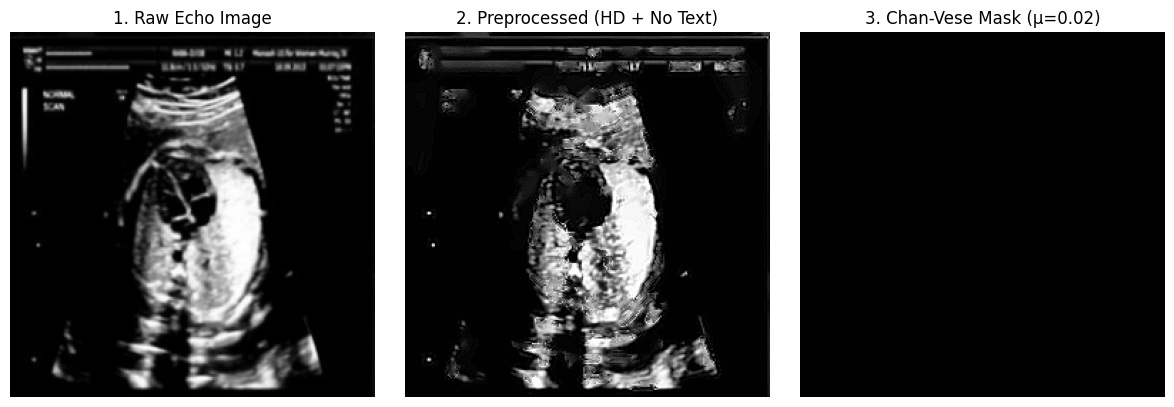

In [11]:
# Preprocess the image using the defined function
preprocessed_img = preprocess_image(SAMPLE_IMAGE_PATH)

# Segment the image to get the mask
resized_raw_img, clean_mask = segment_clean_cardiac_chambers(SAMPLE_IMAGE_PATH)

# Verify the preprocessing and segmentation visually
if preprocessed_img is not None and resized_raw_img is not None and clean_mask is not None:
    verify_preprocessing_and_segmentation(SAMPLE_IMAGE_PATH, preprocessed_img, clean_mask)
else:
    print(f"Could not process image: {SAMPLE_IMAGE_PATH}. Check path and content.")